# Exploring the USA Artifact

This notebook visually explores the USA-level artifact built by population-weighted
aggregation of all 51 state artifacts.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ARTIFACT_DIR = Path('../src/vivarium_nih_us_cvd/artifacts')
USA_PATH = ARTIFACT_DIR / 'united_states_of_america.hdf'
AL_PATH = ARTIFACT_DIR / 'alabama.hdf'
CA_PATH = ARTIFACT_DIR / 'california.hdf'

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

## 1. Artifact Key Inventory

In [4]:
with pd.HDFStore(str(USA_PATH), 'r') as store:
    usa_keys = sorted(store.keys())

print(f'Total DataFrame keys: {len(usa_keys)}\n')
for k in usa_keys:
    df = pd.read_hdf(USA_PATH, k)
    draw_cols = [c for c in df.columns if c.startswith('draw_')]
    other_cols = [c for c in df.columns if not c.startswith('draw_')]
    print(f'{k:75s}  shape={str(df.shape):12s}  index={df.index.names}  cols={other_cols if other_cols else f"{len(draw_cols)} draws"}')

Total DataFrame keys: 54

/cause/acute_myocardial_infarction/disability_weight                         shape=(46, 1000)    index=['sex', 'age_start', 'age_end', 'year_start', 'year_end']  cols=1000 draws
/cause/acute_myocardial_infarction/excess_mortality_rate                     shape=(46, 1000)    index=['sex', 'age_start', 'age_end', 'year_start', 'year_end']  cols=1000 draws
/cause/acute_myocardial_infarction/incidence_rate                            shape=(46, 1000)    index=['sex', 'age_start', 'age_end', 'year_start', 'year_end']  cols=1000 draws
/cause/acute_myocardial_infarction/prevalence                                shape=(46, 1000)    index=['sex', 'age_start', 'age_end', 'year_start', 'year_end']  cols=1000 draws
/cause/acute_myocardial_infarction_and_heart_failure/prevalence              shape=(46, 1000)    index=['sex', 'age_start', 'age_end', 'year_start', 'year_end']  cols=1000 draws
/cause/all_causes/cause_specific_mortality_rate                              shape=(

## 2. Population Structure

Total US population: 327,978,730



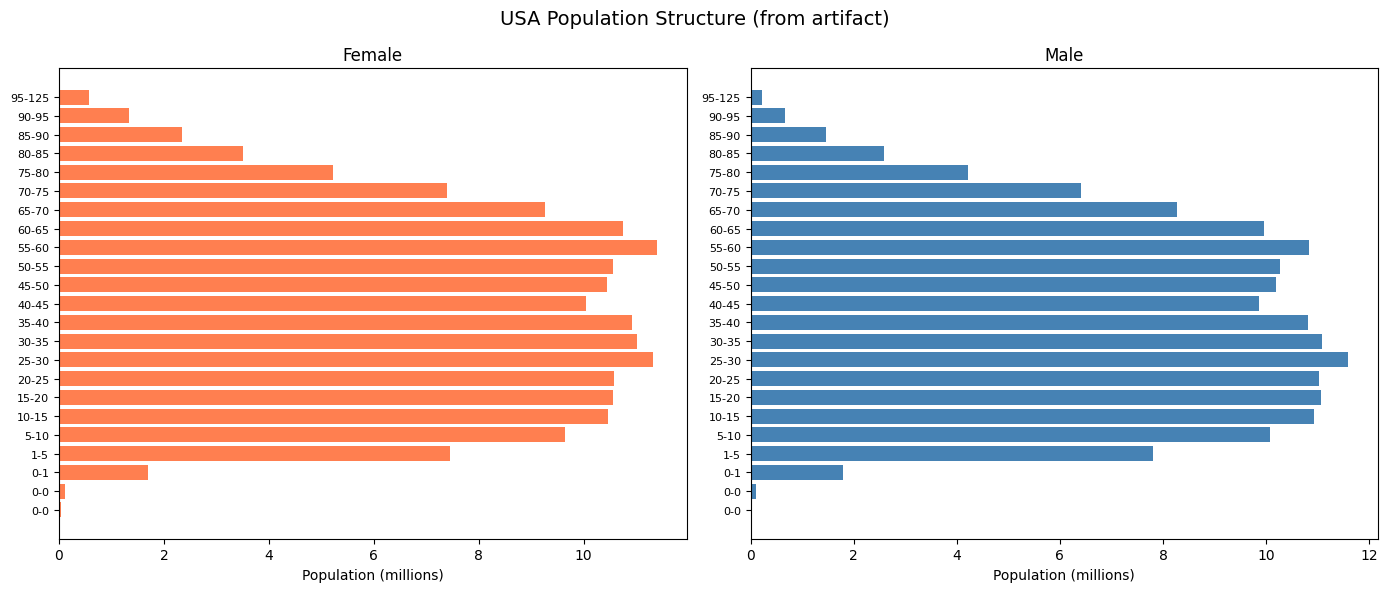

In [5]:
us_pop = pd.read_hdf(USA_PATH, '/population/structure').reset_index()
if 'location' in us_pop.columns:
    us_pop = us_pop.drop(columns=['location'])
print(f'Total US population: {us_pop["value"].sum():,.0f}\n')

# Age pyramid
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for sex, ax in zip(['Female', 'Male'], axes):
    data = us_pop[us_pop['sex'] == sex].sort_values('age_start')
    age_labels = [f"{int(a)}-{int(b)}" for a, b in zip(data['age_start'], data['age_end'])]
    ax.barh(range(len(data)), data['value'] / 1e6, color='steelblue' if sex == 'Male' else 'coral')
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(age_labels, fontsize=8)
    ax.set_xlabel('Population (millions)')
    ax.set_title(f'{sex}')

fig.suptitle('USA Population Structure (from artifact)', fontsize=14)
plt.tight_layout()
plt.show()

## 3. State-level Population Comparison

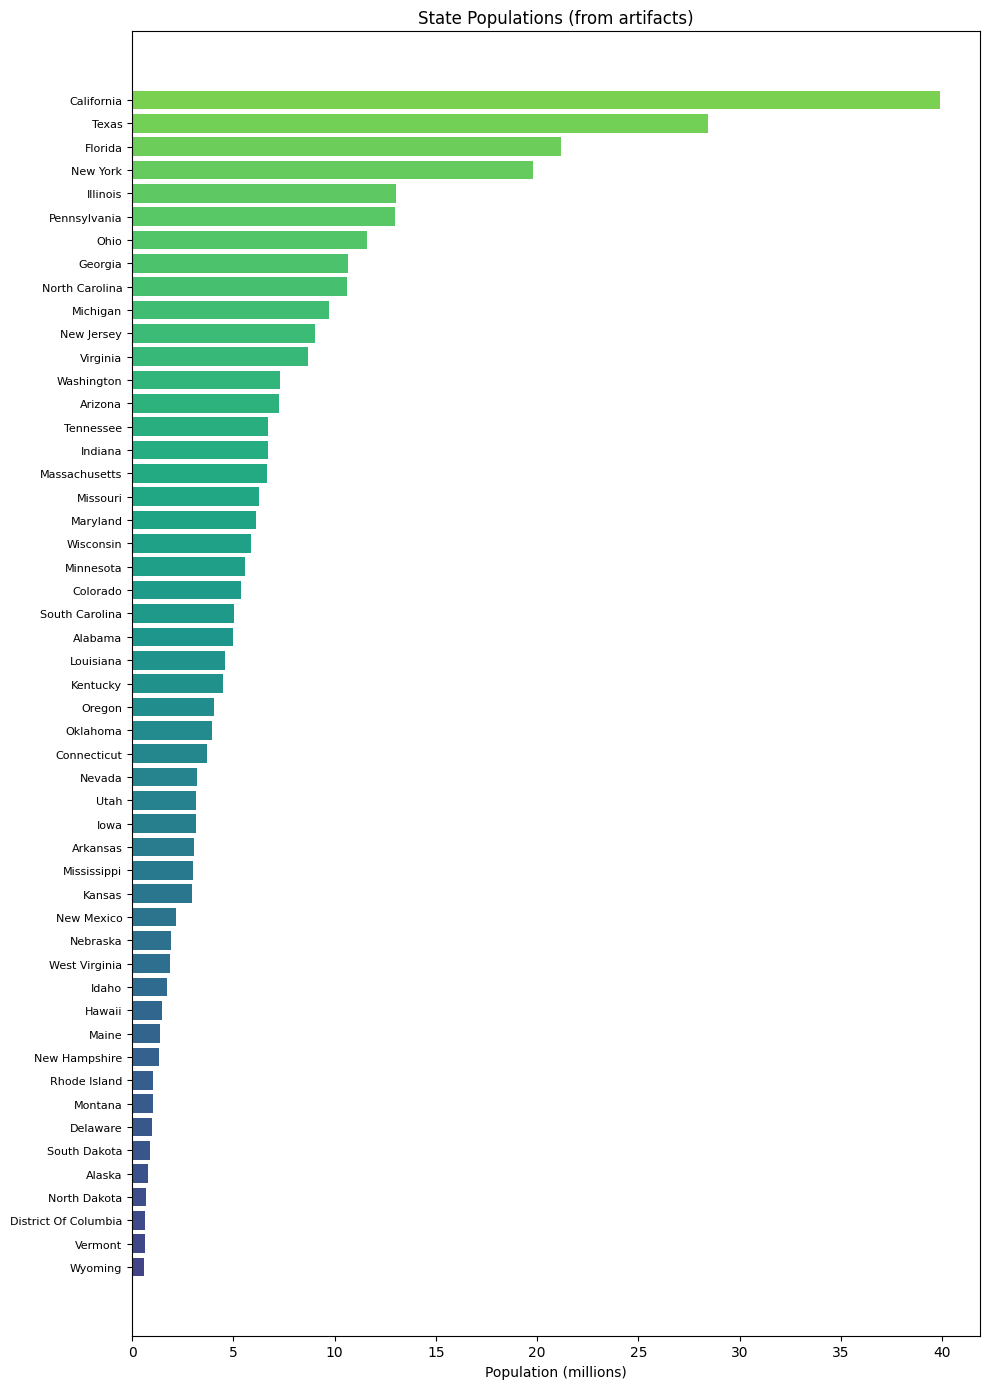

Sum of state populations: 327,978,730
USA artifact total:       327,978,730


In [6]:
# Show top/bottom states by population
state_pops = {}
for f in sorted(ARTIFACT_DIR.glob('*.hdf')):
    if f.stem == 'united_states_of_america':
        continue
    pop = pd.read_hdf(f, '/population/structure')
    state_pops[f.stem.replace('_', ' ').title()] = pop['value'].sum()

state_pops = pd.Series(state_pops).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 14))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(state_pops)))
ax.barh(range(len(state_pops)), state_pops.values / 1e6, color=colors)
ax.set_yticks(range(len(state_pops)))
ax.set_yticklabels(state_pops.index, fontsize=8)
ax.set_xlabel('Population (millions)')
ax.set_title('State Populations (from artifacts)')
plt.tight_layout()
plt.show()

print(f'Sum of state populations: {state_pops.sum():,.0f}')
print(f'USA artifact total:       {us_pop["value"].sum():,.0f}')

## 4. Disease Rates: USA vs Selected States

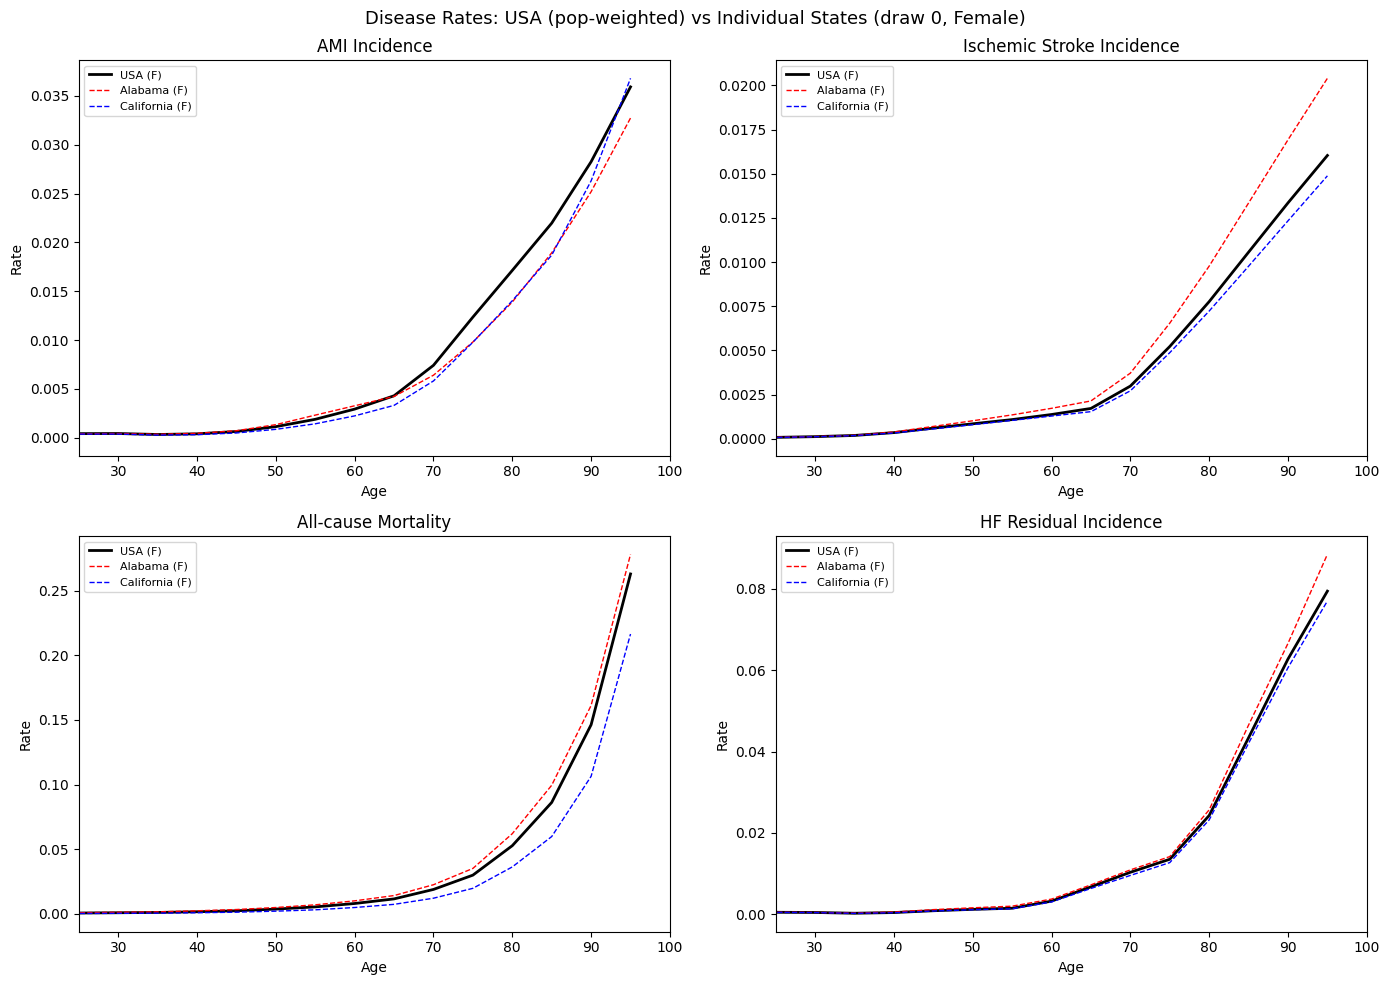

In [7]:
def load_rate(path, key, draw='draw_0'):
    """Load a rate from artifact and return as age-sex DataFrame."""
    df = pd.read_hdf(path, key)
    if draw in df.columns:
        df = df[[draw]].rename(columns={draw: 'value'})
    return df.reset_index()

rate_keys = {
    'AMI Incidence': '/cause/acute_myocardial_infarction/incidence_rate',
    'Ischemic Stroke Incidence': '/cause/ischemic_stroke/incidence_rate',
    'All-cause Mortality': '/cause/all_causes/cause_specific_mortality_rate',
    'HF Residual Incidence': '/cause/heart_failure_residual/incidence_rate',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (title, key) in zip(axes.flat, rate_keys.items()):
    for label, path, color, ls in [
        ('USA', USA_PATH, 'black', '-'),
        ('Alabama', AL_PATH, 'red', '--'),
        ('California', CA_PATH, 'blue', '--'),
    ]:
        df = load_rate(path, key)
        # Plot females only for clarity
        fem = df[df['sex'] == 'Female'].sort_values('age_start')
        ax.plot(fem['age_start'], fem['value'], label=f'{label} (F)',
                color=color, linestyle=ls, linewidth=2 if label == 'USA' else 1)
    ax.set_title(title)
    ax.set_xlabel('Age')
    ax.set_ylabel('Rate')
    ax.legend(fontsize=8)
    ax.set_xlim(25, 100)

fig.suptitle('Disease Rates: USA (pop-weighted) vs Individual States (draw 0, Female)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Risk Factor Exposures

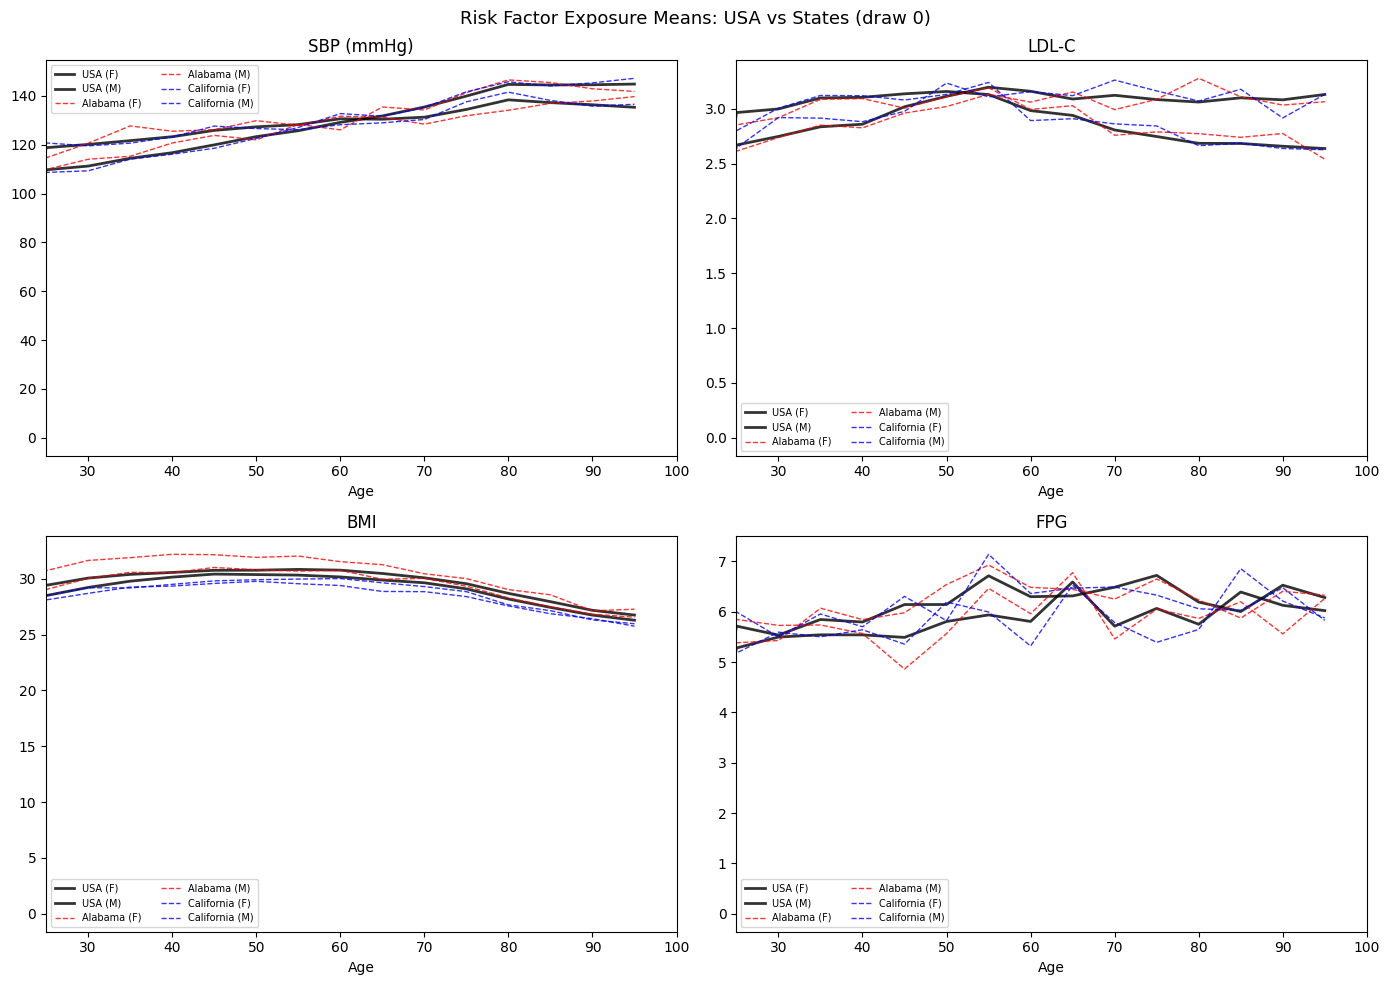

In [8]:
exposure_keys = {
    'SBP (mmHg)': '/risk_factor/high_systolic_blood_pressure/exposure',
    'LDL-C': '/risk_factor/high_ldl_cholesterol/exposure',
    'BMI': '/risk_factor/high_body_mass_index_in_adults/exposure',
    'FPG': '/risk_factor/high_fasting_plasma_glucose/exposure',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (title, key) in zip(axes.flat, exposure_keys.items()):
    for label, path, color, ls in [
        ('USA', USA_PATH, 'black', '-'),
        ('Alabama', AL_PATH, 'red', '--'),
        ('California', CA_PATH, 'blue', '--'),
    ]:
        df = load_rate(path, key)
        for sex, marker in [('Female', 'o'), ('Male', 's')]:
            sub = df[df['sex'] == sex].sort_values('age_start')
            ax.plot(sub['age_start'], sub['value'],
                    label=f'{label} ({sex[0]})', color=color, linestyle=ls,
                    linewidth=2 if label == 'USA' else 1, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('Age')
    ax.legend(fontsize=7, ncol=2)
    ax.set_xlim(25, 100)

fig.suptitle('Risk Factor Exposure Means: USA vs States (draw 0)', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Joint PAFs

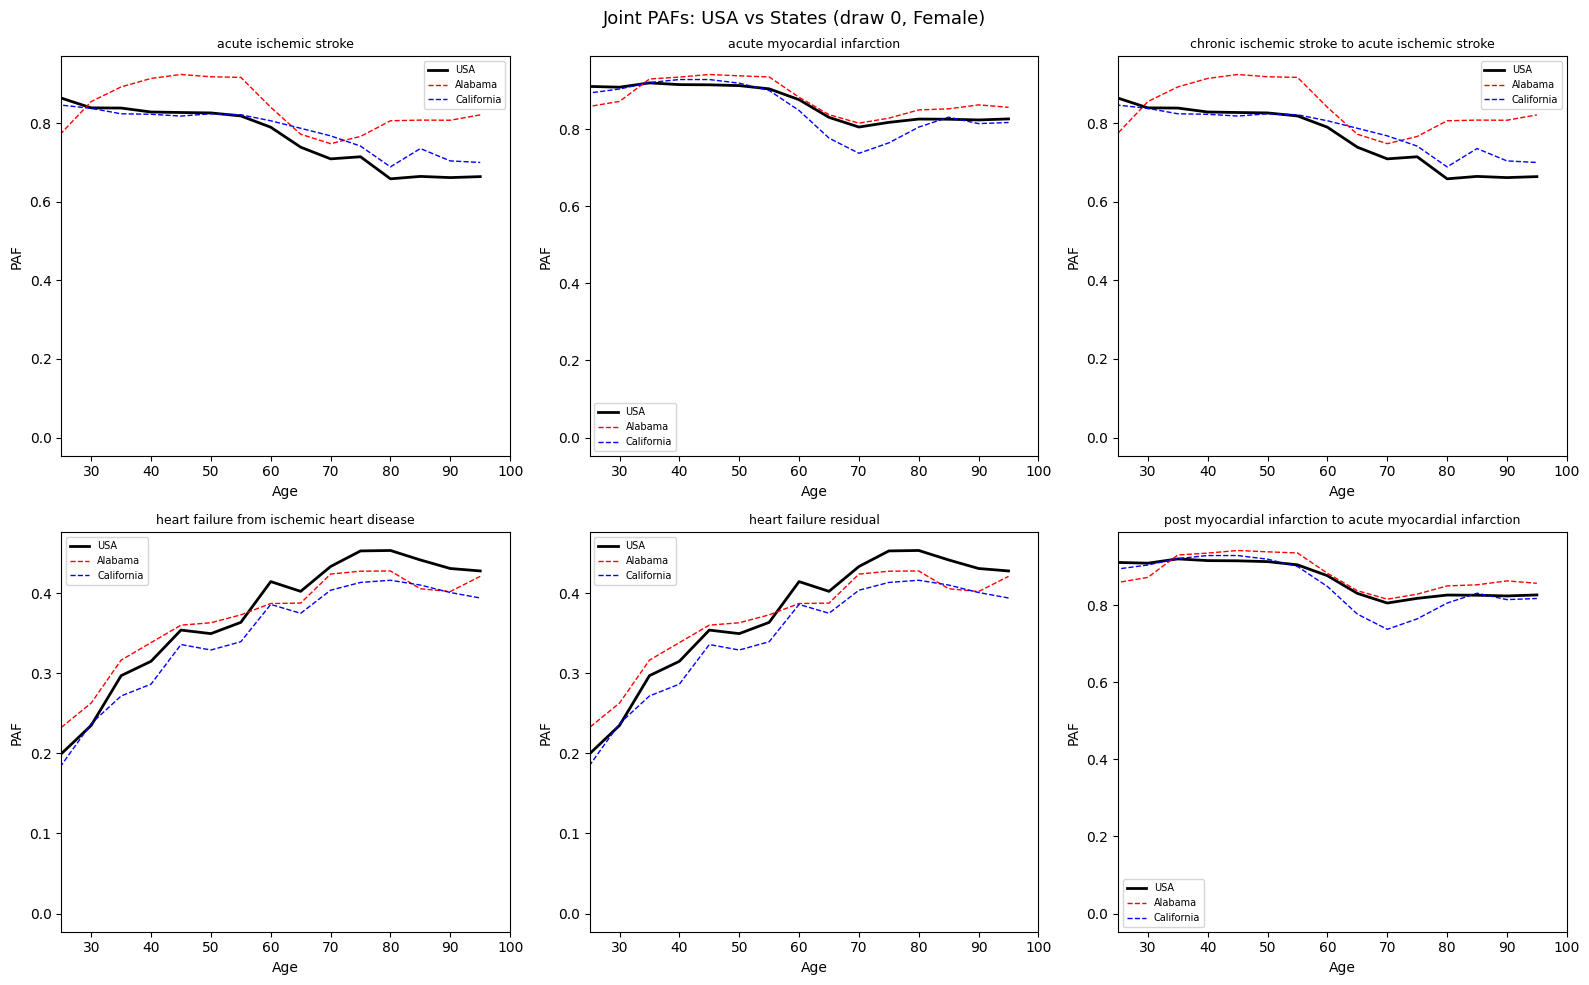

In [9]:
us_pafs = pd.read_hdf(USA_PATH, '/risk_factor/joint_mediated_risks/population_attributable_fraction')
us_pafs = us_pafs[['draw_0']].rename(columns={'draw_0': 'value'}).reset_index()

entities = us_pafs['affected_entity'].unique()
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, entity in zip(axes.flat, entities):
    for label, path, color in [('USA', USA_PATH, 'black'), ('Alabama', AL_PATH, 'red'), ('California', CA_PATH, 'blue')]:
        df = pd.read_hdf(path, '/risk_factor/joint_mediated_risks/population_attributable_fraction')
        df = df[['draw_0']].rename(columns={'draw_0': 'value'}).reset_index()
        sub = df[(df['affected_entity'] == entity) & (df['sex'] == 'Female')].sort_values('age_start')
        ax.plot(sub['age_start'], sub['value'], label=label, color=color,
                linewidth=2 if label == 'USA' else 1, linestyle='-' if label == 'USA' else '--')
    ax.set_title(entity.replace('_', ' '), fontsize=9)
    ax.set_xlabel('Age')
    ax.set_ylabel('PAF')
    ax.legend(fontsize=7)
    ax.set_xlim(25, 100)

fig.suptitle('Joint PAFs: USA vs States (draw 0, Female)', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Cross-State Variability for Key Measures

Shows the distribution of state-level values compared to the USA aggregate.

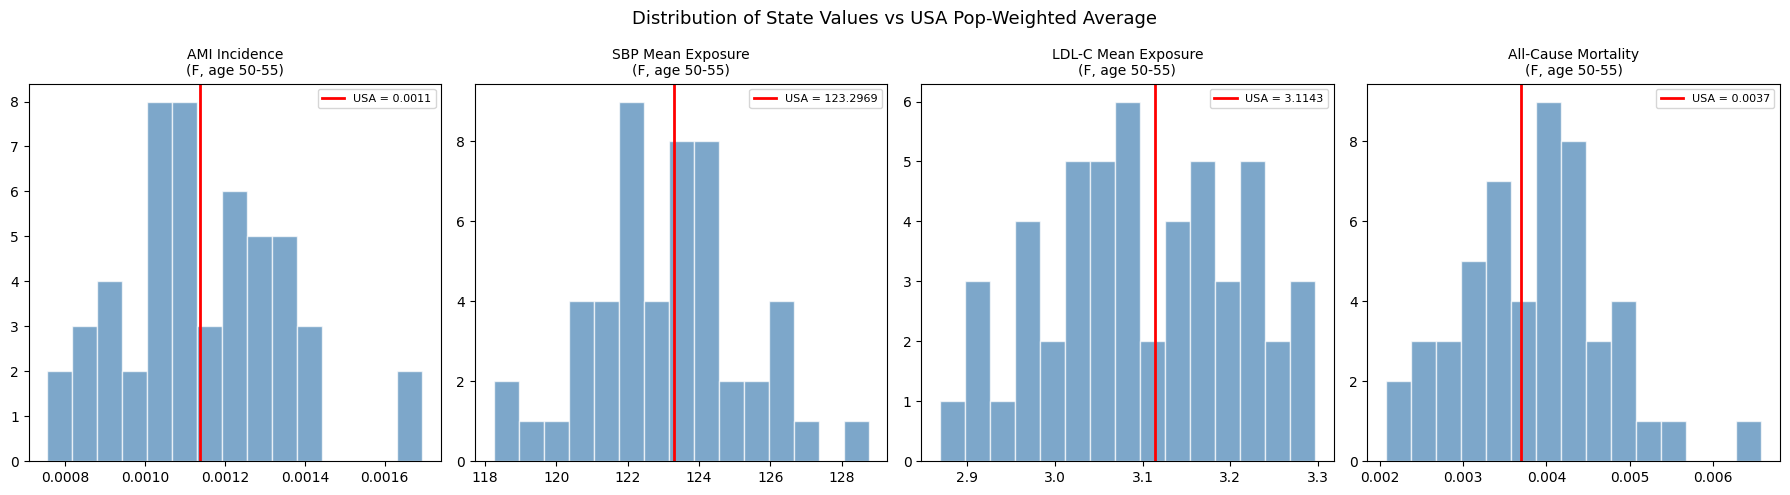

In [10]:
# For a few key measures, show how state values distribute around USA value
# Focus on ages 50-55, Female, draw_0
measures = {
    'AMI Incidence': '/cause/acute_myocardial_infarction/incidence_rate',
    'SBP Mean Exposure': '/risk_factor/high_systolic_blood_pressure/exposure',
    'LDL-C Mean Exposure': '/risk_factor/high_ldl_cholesterol/exposure',
    'All-Cause Mortality': '/cause/all_causes/cause_specific_mortality_rate',
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, (title, key) in zip(axes, measures.items()):
    state_vals = []
    for f in sorted(ARTIFACT_DIR.glob('*.hdf')):
        if f.stem == 'united_states_of_america':
            continue
        df = pd.read_hdf(f, key)
        df = df[['draw_0']].rename(columns={'draw_0': 'value'}).reset_index()
        row = df[(df['sex'] == 'Female') & (df['age_start'] >= 50) & (df['age_start'] < 55)]
        if len(row) > 0:
            state_vals.append(row['value'].values[0])

    # USA value
    us_df = pd.read_hdf(USA_PATH, key)
    us_df = us_df[['draw_0']].rename(columns={'draw_0': 'value'}).reset_index()
    us_row = us_df[(us_df['sex'] == 'Female') & (us_df['age_start'] >= 50) & (us_df['age_start'] < 55)]
    us_val = us_row['value'].values[0]

    ax.hist(state_vals, bins=15, alpha=0.7, color='steelblue', edgecolor='white')
    ax.axvline(us_val, color='red', linewidth=2, label=f'USA = {us_val:.4f}')
    ax.set_title(f'{title}\n(F, age 50-55)', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Distribution of State Values vs USA Pop-Weighted Average', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Medication Adherence & Coverage

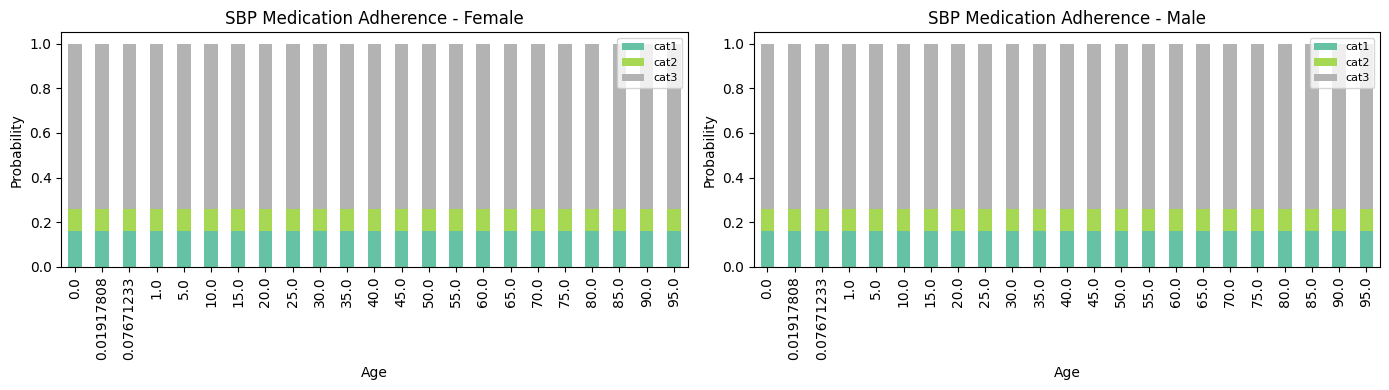

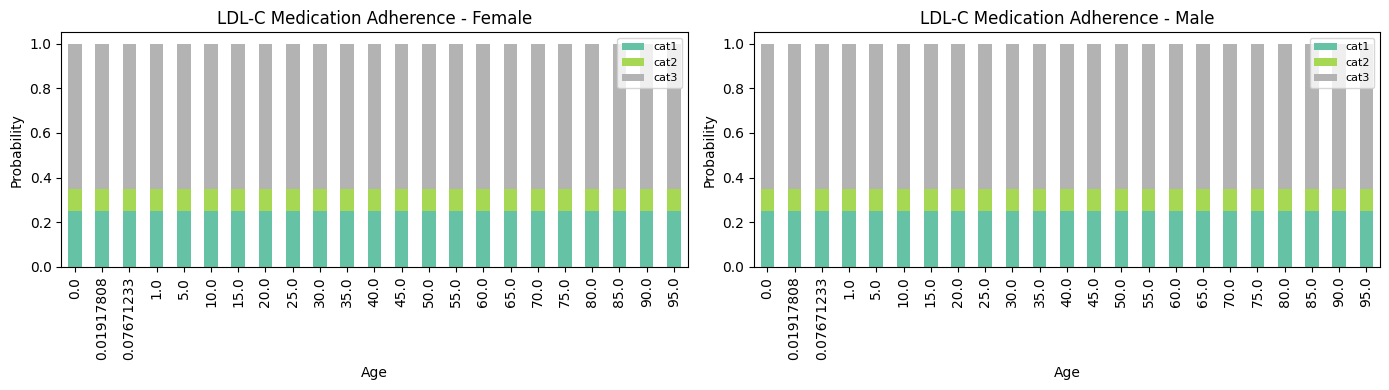

In [11]:
for title, key in [('SBP Medication Adherence', '/risk_factor/sbp_medication_adherence/exposure'),
                    ('LDL-C Medication Adherence', '/risk_factor/ldlc_medication_adherence/exposure')]:
    df = pd.read_hdf(USA_PATH, key)
    df = df[['draw_0']].rename(columns={'draw_0': 'value'}).reset_index()
    if 'location' in df.columns:
        df = df.drop(columns=['location'])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, sex in zip(axes, ['Female', 'Male']):
        sub = df[df['sex'] == sex].pivot(index='age_start', columns='parameter', values='value')
        sub.plot.bar(stacked=True, ax=ax, colormap='Set2')
        ax.set_title(f'{title} - {sex}')
        ax.set_xlabel('Age')
        ax.set_ylabel('Probability')
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 9. Draw Uncertainty (SBP Exposure)

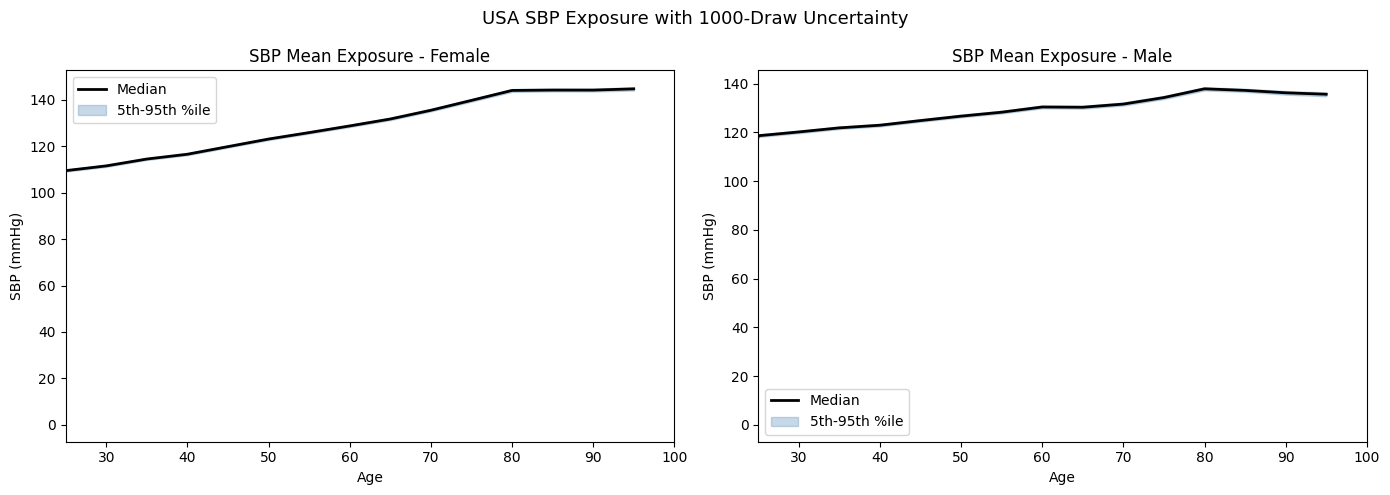

Number of draws: 1000


In [12]:
sbp = pd.read_hdf(USA_PATH, '/risk_factor/high_systolic_blood_pressure/exposure')
draw_cols = [c for c in sbp.columns if c.startswith('draw_')]
sbp_reset = sbp.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sex in zip(axes, ['Female', 'Male']):
    sub = sbp_reset[sbp_reset['sex'] == sex].sort_values('age_start')
    ages = sub['age_start'].values
    vals = sub[draw_cols].values
    
    median = np.median(vals, axis=1)
    p5 = np.percentile(vals, 5, axis=1)
    p95 = np.percentile(vals, 95, axis=1)
    
    ax.plot(ages, median, 'k-', linewidth=2, label='Median')
    ax.fill_between(ages, p5, p95, alpha=0.3, color='steelblue', label='5th-95th %ile')
    ax.set_title(f'SBP Mean Exposure - {sex}')
    ax.set_xlabel('Age')
    ax.set_ylabel('SBP (mmHg)')
    ax.legend()
    ax.set_xlim(25, 100)

fig.suptitle('USA SBP Exposure with 1000-Draw Uncertainty', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Number of draws: {len(draw_cols)}')

## 10. Prevalence Summary

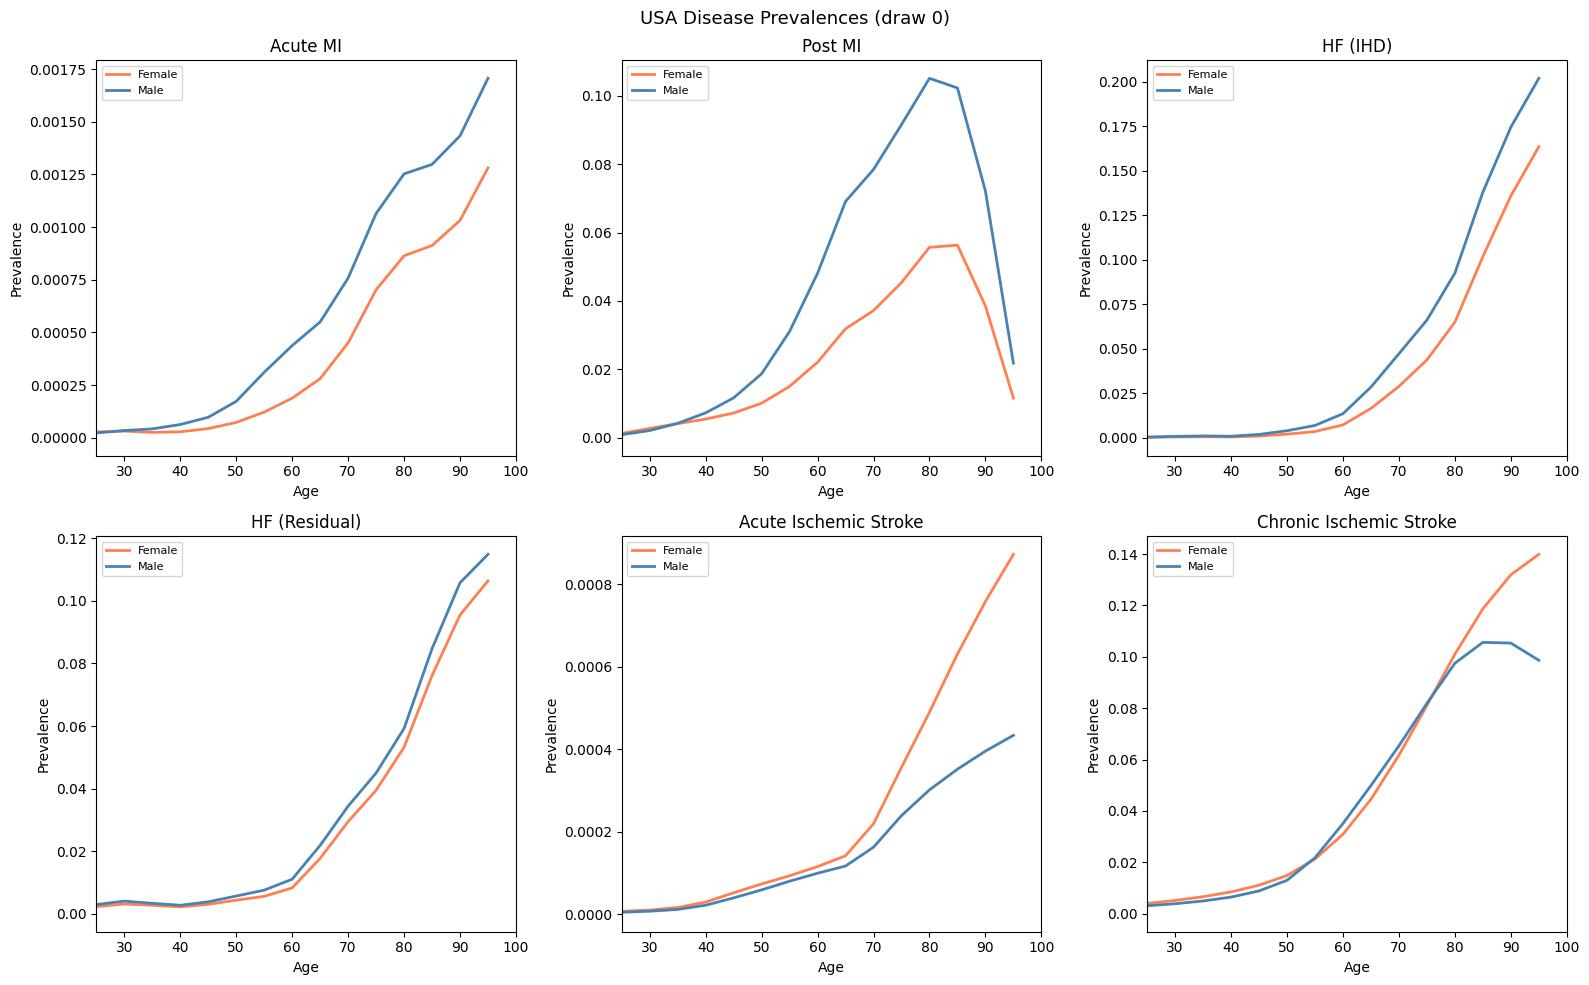

In [14]:
prev_keys = {
    'Acute MI': '/cause/acute_myocardial_infarction/prevalence',
    'Post MI': '/cause/post_myocardial_infarction/prevalence',
    'HF (IHD)': '/cause/heart_failure_from_ischemic_heart_disease/prevalence',
    'HF (Residual)': '/cause/heart_failure_residual/prevalence',
    'Acute Ischemic Stroke': '/sequela/acute_ischemic_stroke/prevalence',
    'Chronic Ischemic Stroke': '/sequela/chronic_ischemic_stroke/prevalence',
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, (title, key) in zip(axes.flat, prev_keys.items()):
    df = load_rate(USA_PATH, key)
    for sex, color in [('Female', 'coral'), ('Male', 'steelblue')]:
        sub = df[df['sex'] == sex].sort_values('age_start')
        ax.plot(sub['age_start'], sub['value'], label=sex, color=color, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel('Age')
    ax.set_ylabel('Prevalence')
    ax.legend(fontsize=8)
    ax.set_xlim(25, 100)

fig.suptitle('USA Disease Prevalences (draw 0)', fontsize=13)
plt.tight_layout()
plt.show()